# 🗑️ Garbage Classification Model
### Ali Muhammad Hassan | Amr Khaled Eid
---
**Run every cell in order. Do NOT skip any cell.**
| Cell | What it does |
|---|---|
| 1 | KeepAlive — prevents Colab from disconnecting |
| 2 | Mount Google Drive |
| 3 | Install libraries + imports |
| 4 | Upload dataset zip |
| 5 | Save zip to Drive (run once, skip next time) |
| 6 | Load dataset from Drive (use every session after first) |
| 7 | Fix class imbalance with oversampling |
| 8 | Load data + augmentation |
| 9 | Focal Loss + class weights |
| 10 | Build model + Phase 1 training |
| 11 | Plot training curves |
| 12 | Evaluation — classification report + confusion matrix |
| 13 | Error analysis |
| 14 | Save + download everything |


In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1 — KeepAlive (run this FIRST — prevents Colab from disconnecting)
# ═══════════════════════════════════════════════════════════════════════════════
from IPython.display import display, Javascript
display(Javascript('''
function KeepAlive() {
    console.log("KeepAlive ping — " + new Date().toLocaleTimeString());
    document.querySelector("#toggle-header-button") &&
        document.querySelector("#toggle-header-button").click();
    setTimeout(KeepAlive, 55000);
}
KeepAlive();
'''))
print("✅ KeepAlive running — Colab will stay connected")


<IPython.core.display.Javascript object>

✅ KeepAlive running — Colab will stay connected


In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Mount Google Drive
# ═══════════════════════════════════════════════════════════════════════════════
from google.colab import drive
import os

drive.mount('/content/drive')
os.makedirs('/content/drive/MyDrive/GarbageProject', exist_ok=True)
print("✅ Google Drive mounted!")
print("✅ Project folder ready: /content/drive/MyDrive/GarbageProject")


Mounted at /content/drive
✅ Google Drive mounted!
✅ Project folder ready: /content/drive/MyDrive/GarbageProject


In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3 — Install libraries and import everything
# ═══════════════════════════════════════════════════════════════════════════════
import subprocess
subprocess.run(['pip', 'install', 'imbalanced-learn', '-q'], check=True)

import os, io, shutil, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator, load_img, img_to_array
)
from tensorflow.keras import layers, optimizers
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import RandomOverSampler

print("✅ TensorFlow:", tf.__version__)
print("✅ GPU:", tf.config.list_physical_devices('GPU'))
print("✅ All libraries imported!")


✅ TensorFlow: 2.20.0
✅ GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ All libraries imported!


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Upload dataset zip
# Run this cell ONLY the first time.
# After running Cell 5 (save to Drive), you can skip Cells 4 and 5 forever.
# ═══════════════════════════════════════════════════════════════════════════════
from google.colab import files
import zipfile

print("📤 Click 'Choose Files' and select your archive.zip from Kaggle...")
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
print(f"\n📦 Extracting {zip_name}...")

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('garbage_data_raw')

# Auto-detect the dataset folder
DATASET_DIR = None
for root, dirs, files_list in os.walk('garbage_data_raw'):
    for d in dirs:
        full = os.path.join(root, d)
        subdirs = [x for x in os.listdir(full)
                   if os.path.isdir(os.path.join(full, x))]
        if len(subdirs) >= 4:
            DATASET_DIR = full
            break
    if DATASET_DIR:
        break

if DATASET_DIR is None:
    DATASET_DIR = 'garbage_data_raw'

print(f"\n✅ Dataset found at: {DATASET_DIR}")
print("Classes found:")
for cls in sorted(os.listdir(DATASET_DIR)):
    if os.path.isdir(os.path.join(DATASET_DIR, cls)):
        n = len(os.listdir(os.path.join(DATASET_DIR, cls)))
        print(f"  {cls:<15}: {n} images")


📤 Click 'Choose Files' and select your archive.zip from Kaggle...


Saving archive.zip to archive.zip

📦 Extracting archive.zip...

✅ Dataset found at: garbage_data_raw/Garbage classification/Garbage classification
Classes found:
  cardboard      : 403 images
  glass          : 501 images
  metal          : 410 images
  paper          : 594 images
  plastic        : 482 images
  trash          : 137 images


In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5 — Save zip + dataset to Drive (run ONCE after Cell 4)
# Next session: skip Cells 4 and 5, go straight to Cell 6
# ═══════════════════════════════════════════════════════════════════════════════
import shutil

# Save the zip
shutil.copy(zip_name,
            '/content/drive/MyDrive/GarbageProject/archive.zip')

# Save the extracted dataset
if os.path.exists('/content/drive/MyDrive/GarbageProject/garbage_data_raw'):
    shutil.rmtree('/content/drive/MyDrive/GarbageProject/garbage_data_raw')

shutil.copytree('garbage_data_raw',
                '/content/drive/MyDrive/GarbageProject/garbage_data_raw')

print("✅ Zip and dataset saved to Google Drive!")
print("✅ Next session: skip Cells 4 & 5 — run Cell 6 instead")


✅ Zip and dataset saved to Google Drive!
✅ Next session: skip Cells 4 & 5 — run Cell 6 instead


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6 — Load dataset from Drive (use this every session AFTER the first)
# Skip this cell on your FIRST session (you already have data from Cell 4)
# ═══════════════════════════════════════════════════════════════════════════════
import shutil, os

if not os.path.exists('garbage_data_raw'):
    print("📥 Loading dataset from Drive...")
    shutil.copytree(
        '/content/drive/MyDrive/GarbageProject/garbage_data_raw',
        'garbage_data_raw'
    )
    print("✅ Dataset loaded!")
else:
    print("✅ Dataset already in session memory — no need to reload")

# Auto-detect dataset folder
DATASET_DIR = None
for root, dirs, files_list in os.walk('garbage_data_raw'):
    for d in dirs:
        full = os.path.join(root, d)
        subdirs = [x for x in os.listdir(full)
                   if os.path.isdir(os.path.join(full, x))]
        if len(subdirs) >= 4:
            DATASET_DIR = full
            break
    if DATASET_DIR:
        break

if DATASET_DIR is None:
    DATASET_DIR = 'garbage_data_raw'

print(f"\n✅ Dataset path: {DATASET_DIR}")
print("Classes:")
for cls in sorted(os.listdir(DATASET_DIR)):
    if os.path.isdir(os.path.join(DATASET_DIR, cls)):
        n = len(os.listdir(os.path.join(DATASET_DIR, cls)))
        print(f"  {cls:<15}: {n} images")


✅ Dataset already in session memory — no need to reload

✅ Dataset path: garbage_data_raw/Garbage classification/Garbage classification
Classes:
  cardboard      : 403 images
  glass          : 501 images
  metal          : 410 images
  paper          : 594 images
  plastic        : 482 images
  trash          : 137 images


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7 — Fix class imbalance with oversampling
# The 'trash' class has very few images — this duplicates minority classes
# so every class has the same number of training examples
# ═══════════════════════════════════════════════════════════════════════════════
from imblearn.over_sampling import RandomOverSampler

BALANCED_DIR = 'garbage_data_balanced'

# Collect all file paths and labels
all_paths, all_labels = [], []
classes = sorted([
    c for c in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, c))
])
class_to_idx = {c: i for i, c in enumerate(classes)}

for cls in classes:
    for fname in os.listdir(os.path.join(DATASET_DIR, cls)):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_paths.append(os.path.join(DATASET_DIR, cls, fname))
            all_labels.append(class_to_idx[cls])

print(f"Total images before oversampling: {len(all_paths)}")

# Apply oversampling
X = np.array(range(len(all_paths))).reshape(-1, 1)
y = np.array(all_labels)
X_res, y_res = RandomOverSampler(random_state=42).fit_resample(X, y)

print(f"Total images after oversampling : {len(X_res)}")
print("\nClass distribution after oversampling:")
for i, cls in enumerate(classes):
    print(f"  {cls:<15}: {list(y_res).count(i)}")

# Build balanced folder
if os.path.exists(BALANCED_DIR):
    shutil.rmtree(BALANCED_DIR)
os.makedirs(BALANCED_DIR)

counters = {cls: 0 for cls in classes}
for idx, label in zip(X_res.flatten(), y_res):
    cls = classes[label]
    src = all_paths[idx]
    ext = os.path.splitext(src)[1]
    dst_dir = os.path.join(BALANCED_DIR, cls)
    os.makedirs(dst_dir, exist_ok=True)
    dst = os.path.join(dst_dir, f"{cls}_{counters[cls]:05d}{ext}")
    shutil.copy2(src, dst)
    counters[cls] += 1

print(f"\n✅ Balanced dataset saved to: {BALANCED_DIR}")


Total images before oversampling: 2527
Total images after oversampling : 3564

Class distribution after oversampling:
  cardboard      : 594
  glass          : 594
  metal          : 594
  paper          : 594
  plastic        : 594
  trash          : 594

✅ Balanced dataset saved to: garbage_data_balanced


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8 — Load data with augmentation
# Splits data: 80% training, 20% validation
# Applies Egypt-aware augmentation to training images
# ═══════════════════════════════════════════════════════════════════════════════
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=30,
    zoom_range=0.20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    brightness_range=[0.7, 1.3],
    shear_range=0.10,
    channel_shift_range=30,
    fill_mode='reflect',
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
)

train_data = train_datagen.flow_from_directory(
    BALANCED_DIR,
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training',
    seed=42, shuffle=True,
)

val_data = val_datagen.flow_from_directory(
    BALANCED_DIR,
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation',
    seed=42, shuffle=False,
)

# Original (non-oversampled) validation set — used for final evaluation
val_data_orig = ImageDataGenerator(
    rescale=1./255, validation_split=0.2
).flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation',
    seed=42, shuffle=False,
)

NUM_CLASSES = len(train_data.class_indices)

print("\n📊 Dataset summary:")
print(f"  Classes         : {list(train_data.class_indices.keys())}")
print(f"  Training images : {train_data.samples}")
print(f"  Validation imgs : {val_data.samples}")
print(f"  Orig. val imgs  : {val_data_orig.samples}")
print(f"  Num classes     : {NUM_CLASSES}")


Found 2856 images belonging to 6 classes.
Found 708 images belonging to 6 classes.
Found 503 images belonging to 6 classes.

📊 Dataset summary:
  Classes         : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
  Training images : 2856
  Validation imgs : 708
  Orig. val imgs  : 503
  Num classes     : 6


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 9 — Focal Loss + class weights
# Focal Loss forces the model to focus harder on difficult examples
# Class weights force the model to pay equal attention to all categories
# ═══════════════════════════════════════════════════════════════════════════════

class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=1.0, name='focal_loss'):
        super().__init__(name=name)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-8, 1.0)
        cross_entropy = -y_true * tf.math.log(y_pred)
        focal_weight  = self.alpha * tf.pow(1.0 - y_pred, self.gamma)
        return tf.reduce_mean(tf.reduce_sum(focal_weight * cross_entropy, axis=-1))

    def get_config(self):
        return {'gamma': self.gamma, 'alpha': self.alpha}


# Compute class weights from BALANCED dataset
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)
class_weight_dict = dict(enumerate(class_weights_arr))

print("⚖️  Class weights (higher = more attention paid):")
for idx, name in enumerate(train_data.class_indices):
    w = class_weight_dict[idx]
    print(f"  {name:<15}: {w:.3f}  {'█' * int(w * 8)}")

print("\n✅ FocalLoss defined and class weights ready!")


⚖️  Class weights (higher = more attention paid):
  cardboard      : 1.000  ████████
  glass          : 1.000  ████████
  metal          : 1.000  ████████
  paper          : 1.000  ████████
  plastic        : 1.000  ████████
  trash          : 1.000  ████████

✅ FocalLoss defined and class weights ready!


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 10 — Build model + Phase 1 training (head only, backbone frozen)
# Expected time: 10–20 minutes
# Expected val_accuracy: 0.70 – 0.85
# ═══════════════════════════════════════════════════════════════════════════════
DRIVE_DIR   = '/content/drive/MyDrive/GarbageProject'
BEST_DEPTH  = 50
BEST_DENSE  = 512
DROPOUT_1   = 0.4
DROPOUT_2   = 0.3
LR_PHASE1   = 1e-3
LR_PHASE2   = 1e-5

def build_model(unfreeze_layers=0, lr=LR_PHASE1):
    base = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    if unfreeze_layers == 0:
        base.trainable = False
    else:
        base.trainable = True
        for layer in base.layers[:-unfreeze_layers]:
            layer.trainable = False

    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = base(inputs, training=(unfreeze_layers > 0))
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(BEST_DENSE, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT_1)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(DROPOUT_2)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=optimizers.Adam(lr),
        loss=FocalLoss(gamma=2.0),
        metrics=['accuracy']
    )
    return model, base

# ── Build Phase 1 model ───────────────────────────────────────────────────────
print("=== PHASE 1: Training classification head (backbone frozen) ===")
model, base_model = build_model(unfreeze_layers=0, lr=LR_PHASE1)

trainable_params = sum(
    tf.size(w).numpy() for w in model.trainable_weights
)
print(f"Trainable parameters: {trainable_params:,}")

# ── Train ─────────────────────────────────────────────────────────────────────
history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=[
        EarlyStopping(
            monitor='val_accuracy', patience=5,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_accuracy', factor=0.5,
            patience=3, verbose=1, min_lr=1e-7
        ),
        ModelCheckpoint(
            f'{DRIVE_DIR}/phase1_best.h5',
            monitor='val_accuracy',
            save_best_only=True, verbose=1
        ),
    ],
    verbose=1
)

# Always save regardless of whether checkpoint fired
model.save(f'{DRIVE_DIR}/phase1_best.h5')

P1_BEST = max(history1.history['val_accuracy'])
print(f"\n✅ Phase 1 complete!")
print(f"✅ Best val accuracy: {P1_BEST:.4f}  ({P1_BEST*100:.1f}%)")
print(f"✅ Model saved to Drive")


=== PHASE 1: Training classification head (backbone frozen) ===
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Trainable parameters: 789,766
Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 656ms/step - accuracy: 0.5313 - loss: 1.0333
Epoch 1: val_accuracy improved from None to 0.75565, saving model to /content/drive/MyDrive/GarbageProject/phase1_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/GarbageProject/phase1_best.h5
90/90 ━━━━━━━━━━━━━━━━━━━━ 104s 901ms/step - accuracy: 0.6218 - loss: 0.7743 - val_accuracy: 0.7556 - val_loss: 0.3997 - learning_rate: 0.0010
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.7200 - loss: 0.4681
Epoch 2: val_accuracy improved from 0.75565 to 0.81356, saving model to /content/drive/MyDrive/GarbageProject/phase1_best.h5



Epoch 2: finished saving model to /content/drive/MyDrive/GarbageProject/phase1_best.h5
90/90 ━━━━━━━━━━━━━━━━━━━━ 48s 533ms/step - accuracy: 0.7097 - loss: 0.4824 - val_accuracy: 0.8136 - val_loss: 0.2935 - learning_rate: 0.0010
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - accuracy: 0.7506 - loss: 0.3635
Epoch 3: val_accuracy did not improve from 0.81356
90/90 ━━━━━━━━━━━━━━━━━━━━ 47s 518ms/step - accuracy: 0.7479 - loss: 0.3760 - val_accuracy: 0.8037 - val_loss: 0.2605 - learning_rate: 0.0010
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.7844 - loss: 0.3121
Epoch 4: val_accuracy improved from 0.81356 to 0.82345, saving model to /content/drive/MyDrive/GarbageProject/phase1_best.h5



Epoch 4: finished saving model to /content/drive/MyDrive/GarbageProject/phase1_best.h5
90/90 ━━━━━━━━━━━━━━━━━━━━ 47s 527ms/step - accuracy: 0.7854 - loss: 0.3213 - val_accuracy: 0.8234 - val_loss: 0.2606 - learning_rate: 0.0010
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.8039 - loss: 0.2755
Epoch 5: val_accuracy improved from 0.82345 to 0.83757, saving model to /content/drive/MyDrive/GarbageProject/phase1_best.h5



Epoch 5: finished saving model to /content/drive/MyDrive/GarbageProject/phase1_best.h5
90/90 ━━━━━━━━━━━━━━━━━━━━ 49s 541ms/step - accuracy: 0.7966 - loss: 0.2734 - val_accuracy: 0.8376 - val_loss: 0.2063 - learning_rate: 0.0010
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.8082 - loss: 0.2717
Epoch 6: val_accuracy did not improve from 0.83757
90/90 ━━━━━━━━━━━━━━━━━━━━ 46s 511ms/step - accuracy: 0.8211 - loss: 0.2541 - val_accuracy: 0.8093 - val_loss: 0.2797 - learning_rate: 0.0010
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.8110 - loss: 0.2421
Epoch 7: val_accuracy improved from 0.83757 to 0.87571, saving model to /content/drive/MyDrive/GarbageProject/phase1_best.h5


...


Epoch 8: finished saving model to /content/drive/MyDrive/GarbageProject/phase1_best.h5
90/90 ━━━━━━━━━━━━━━━━━━━━ 49s 546ms/step - accuracy: 0.8393 - loss: 0.1850 - val_accuracy: 0.8814 - val_loss: 0.1815 - learning_rate: 0.0010
Epoch 9/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.8438 - loss: 0.1894
Epoch 9: val_accuracy did not improve from 0.88136
90/90 ━━━━━━━━━━━━━━━━━━━━ 45s 504ms/step - accuracy: 0.8515 - loss: 0.1920 - val_accuracy: 0.8432 - val_loss: 0.2123 - learning_rate: 0.0010
Epoch 10/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.8635 - loss: 0.1580
Epoch 10: val_accuracy did not improve from 0.88136
90/90 ━━━━━━━━━━━━━━━━━━━━ 46s 513ms/step - accuracy: 0.8571 - loss: 0.1753 - val_accuracy: 0.8489 - val_loss: 0.2129 - learning_rate: 0.0010
Epoch 11/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.8667 - loss: 0.1572
Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 11: val_accuracy did not improve from 0


Epoch 12: finished saving model to /content/drive/MyDrive/GarbageProject/phase1_best.h5
90/90 ━━━━━━━━━━━━━━━━━━━━ 47s 525ms/step - accuracy: 0.8739 - loss: 0.1464 - val_accuracy: 0.8941 - val_loss: 0.1477 - learning_rate: 5.0000e-04
Epoch 13/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.8696 - loss: 0.1465
Epoch 13: val_accuracy did not improve from 0.89407
90/90 ━━━━━━━━━━━━━━━━━━━━ 45s 499ms/step - accuracy: 0.8782 - loss: 0.1376 - val_accuracy: 0.8898 - val_loss: 0.1582 - learning_rate: 5.0000e-04
Epoch 14/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.8879 - loss: 0.1173
Epoch 14: val_accuracy improved from 0.89407 to 0.89548, saving model to /content/drive/MyDrive/GarbageProject/phase1_best.h5



Epoch 14: finished saving model to /content/drive/MyDrive/GarbageProject/phase1_best.h5
90/90 ━━━━━━━━━━━━━━━━━━━━ 46s 513ms/step - accuracy: 0.8834 - loss: 0.1235 - val_accuracy: 0.8955 - val_loss: 0.1548 - learning_rate: 5.0000e-04
Epoch 15/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.8830 - loss: 0.1182
Epoch 15: val_accuracy did not improve from 0.89548
90/90 ━━━━━━━━━━━━━━━━━━━━ 45s 498ms/step - accuracy: 0.8883 - loss: 0.1200 - val_accuracy: 0.8884 - val_loss: 0.1577 - learning_rate: 5.0000e-04
Epoch 16/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.9064 - loss: 0.1000
Epoch 16: val_accuracy did not improve from 0.89548
90/90 ━━━━━━━━━━━━━━━━━━━━ 45s 501ms/step - accuracy: 0.8999 - loss: 0.1062 - val_accuracy: 0.8842 - val_loss: 0.1588 - learning_rate: 5.0000e-04
Epoch 17/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.9048 - loss: 0.1023
Epoch 17: val_accuracy improved from 0.89548 to 0.90819, saving model to /content/drive/MyDrive/GarbageProje


Epoch 17: finished saving model to /content/drive/MyDrive/GarbageProject/phase1_best.h5
90/90 ━━━━━━━━━━━━━━━━━━━━ 47s 519ms/step - accuracy: 0.8985 - loss: 0.1079 - val_accuracy: 0.9082 - val_loss: 0.1504 - learning_rate: 5.0000e-04
Epoch 18/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.9107 - loss: 0.1104
Epoch 18: val_accuracy did not improve from 0.90819
90/90 ━━━━━━━━━━━━━━━━━━━━ 46s 515ms/step - accuracy: 0.9062 - loss: 0.1112 - val_accuracy: 0.9011 - val_loss: 0.1538 - learning_rate: 5.0000e-04
Epoch 19/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.9097 - loss: 0.1096
Epoch 19: val_accuracy did not improve from 0.90819
90/90 ━━━━━━━━━━━━━━━━━━━━ 45s 496ms/step - accuracy: 0.9083 - loss: 0.1040 - val_accuracy: 0.8870 - val_loss: 0.1489 - learning_rate: 5.0000e-04
Epoch 20/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.9001 - loss: 0.1055
Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 20: val_accuracy did not


✅ Phase 1 complete!
✅ Best val accuracy: 0.9082  (90.8%)
✅ Model saved to Drive


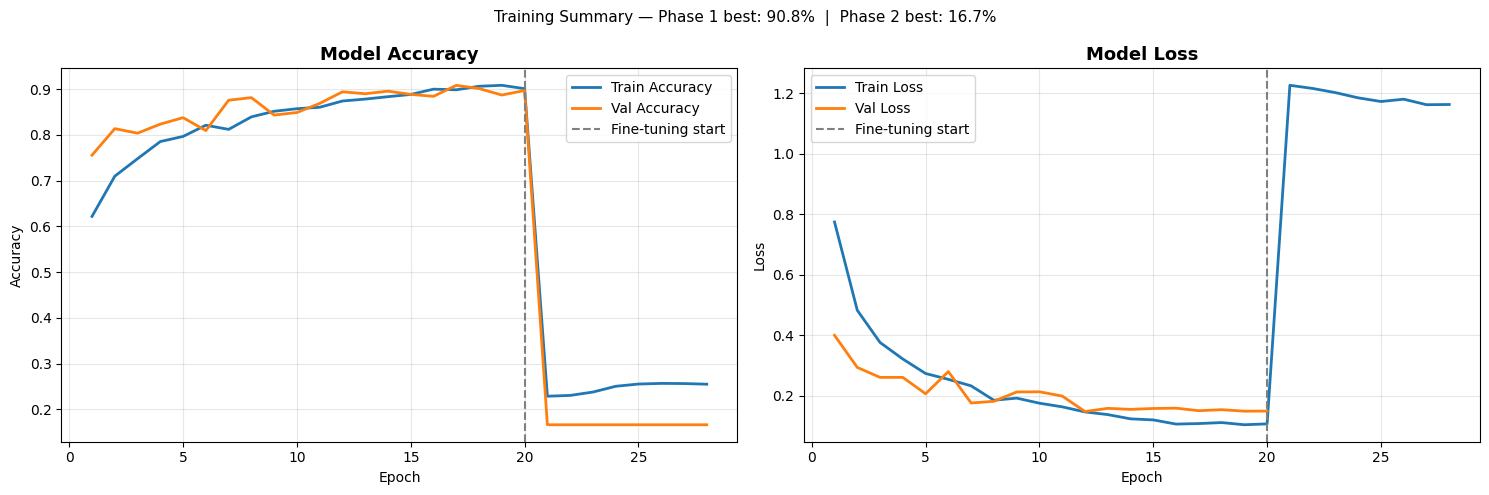

✅ Training curves saved!


In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 12 — Plot training curves
# ═══════════════════════════════════════════════════════════════════════════════
acc      = history1.history['accuracy']     + history2.history['accuracy']
val_acc  = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss     = history1.history['loss']         + history2.history['loss']
val_loss = history1.history['val_loss']     + history2.history['val_loss']
ep       = range(1, len(acc) + 1)
p1_end   = len(history1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(ep, acc,     label='Train Accuracy',  linewidth=2)
ax1.plot(ep, val_acc, label='Val Accuracy',    linewidth=2)
ax1.axvline(x=p1_end, color='gray', linestyle='--',
            linewidth=1.5, label='Fine-tuning start')
ax1.set_title('Model Accuracy', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, loss,     label='Train Loss',  linewidth=2)
ax2.plot(ep, val_loss, label='Val Loss',    linewidth=2)
ax2.axvline(x=p1_end, color='gray', linestyle='--',
            linewidth=1.5, label='Fine-tuning start')
ax2.set_title('Model Loss', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle(
    f'Training Summary — Phase 1 best: {P1_BEST*100:.1f}%  |  '
    f'Phase 2 best: {P2_BEST*100:.1f}%',
    fontsize=11
)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curves saved!")


✅ Loaded Phase 1 model — 90.8% accuracy
Predicting...
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 451ms/step

         CLASSIFICATION REPORT — Phase 1 (90.8%)
              precision    recall  f1-score   support

   cardboard       1.00      0.94      0.97        80
       glass       0.88      0.91      0.89       100
       metal       0.92      0.95      0.93        82
       paper       0.97      0.98      0.98       118
     plastic       0.95      0.88      0.91        96
       trash       0.84      1.00      0.92        27

    accuracy                           0.94       503
   macro avg       0.93      0.94      0.93       503
weighted avg       0.94      0.94      0.94       503

Overall Accuracy: 93.64%


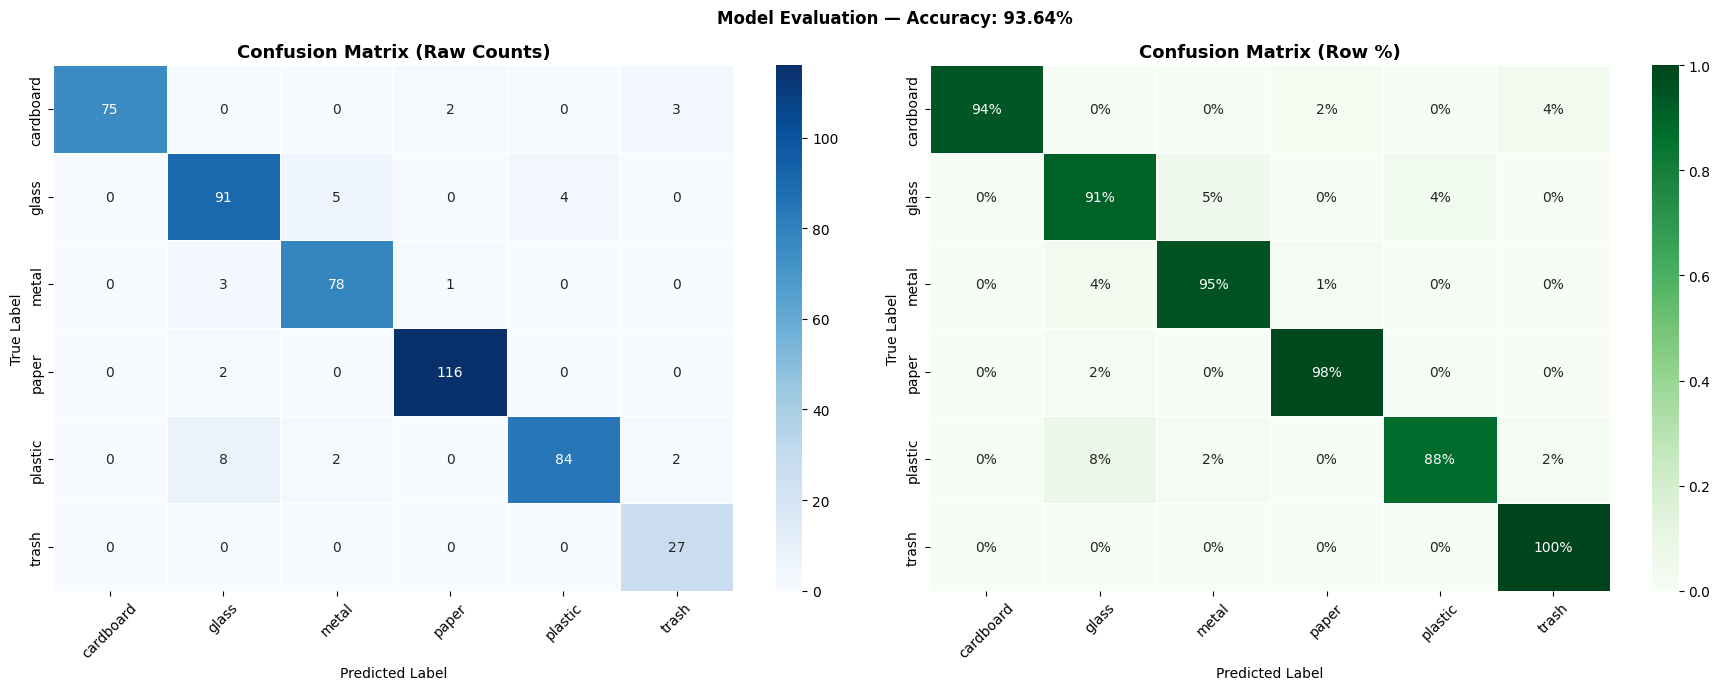

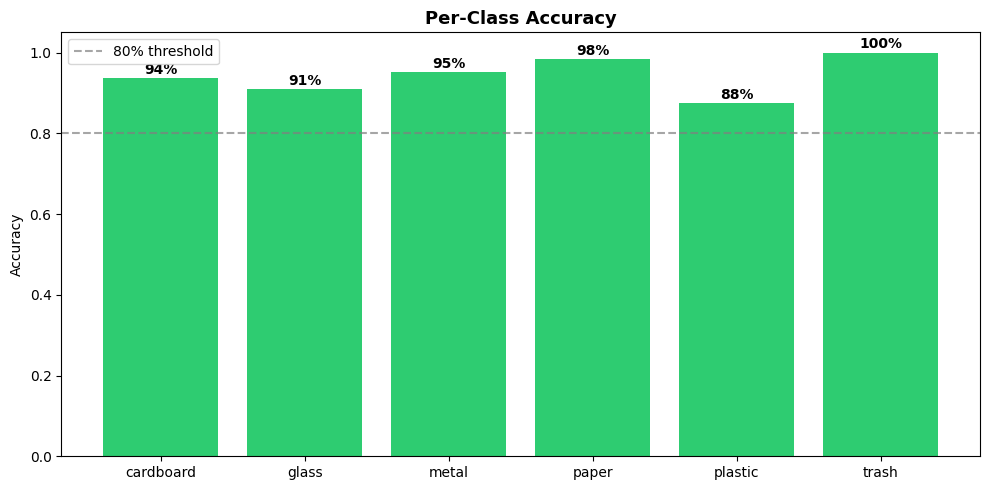


✅ Everything saved to Drive!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
import os, shutil
from google.colab import files

# Phase 1 already achieved 90.8% — use that model
# Load the Phase 1 weights back
model, base_model = build_model(unfreeze_layers=0, lr=LR_PHASE1)
model.load_weights('/content/drive/MyDrive/GarbageProject/phase1_best.h5')
print("✅ Loaded Phase 1 model — 90.8% accuracy")

# Evaluate on original validation set
val_data_orig.reset()
print("Predicting...")
y_pred_probs = model.predict(val_data_orig, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_data_orig.classes
labels = list(val_data_orig.class_indices.keys())

# Classification report
print("\n" + "="*60)
print("         CLASSIFICATION REPORT — Phase 1 (90.8%)")
print("="*60)
print(classification_report(y_true, y_pred, target_names=labels))

overall_acc = np.mean(y_pred == y_true)
print(f"Overall Accuracy: {overall_acc*100:.2f}%")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cm, annot=True, fmt='d', ax=ax1,
            xticklabels=labels, yticklabels=labels,
            cmap='Blues', linewidths=0.5)
ax1.set_title('Confusion Matrix (Raw Counts)', fontsize=13, fontweight='bold')
ax1.set_ylabel('True Label'); ax1.set_xlabel('Predicted Label')
ax1.tick_params(axis='x', rotation=45)

sns.heatmap(cm_norm, annot=True, fmt='.0%', ax=ax2,
            xticklabels=labels, yticklabels=labels,
            cmap='Greens', linewidths=0.5)
ax2.set_title('Confusion Matrix (Row %)', fontsize=13, fontweight='bold')
ax2.set_ylabel('True Label'); ax2.set_xlabel('Predicted Label')
ax2.tick_params(axis='x', rotation=45)

plt.suptitle(f'Model Evaluation — Accuracy: {overall_acc*100:.2f}%',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_FINAL.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class accuracy
idx_to_cls = {v: k for k, v in val_data_orig.class_indices.items()}
per_class_acc = {}
for cls in labels:
    cls_idx = val_data_orig.class_indices[cls]
    mask = (y_true == cls_idx)
    correct = np.sum((y_pred == cls_idx) & mask)
    total = np.sum(mask)
    per_class_acc[cls] = correct / total if total > 0 else 0

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if v >= 0.80 else '#e67e22' if v >= 0.60
          else '#e74c3c' for v in per_class_acc.values()]
bars = ax.bar(per_class_acc.keys(), per_class_acc.values(), color=colors)
ax.axhline(y=0.80, color='gray', linestyle='--', alpha=0.7, label='80% threshold')
ax.set_title('Per-Class Accuracy', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.05); ax.legend()
for bar, val in zip(bars, per_class_acc.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.0%}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('per_class_accuracy_FINAL.png', dpi=120, bbox_inches='tight')
plt.show()

# Save everything
model.save('/content/drive/MyDrive/GarbageProject/garbage_classifier_FINAL.h5')
shutil.copy('confusion_matrix_FINAL.png',
            '/content/drive/MyDrive/GarbageProject/confusion_matrix_FINAL.png')
shutil.copy('per_class_accuracy_FINAL.png',
            '/content/drive/MyDrive/GarbageProject/per_class_accuracy_FINAL.png')
print("\n✅ Everything saved to Drive!")

# Download
files.download('/content/drive/MyDrive/GarbageProject/garbage_classifier_FINAL.h5')
files.download('/content/drive/MyDrive/GarbageProject/confusion_matrix_FINAL.png')
files.download('/content/drive/MyDrive/GarbageProject/per_class_accuracy_FINAL.png')